# Age × Medical Condition Heatmap

This notebook creates a heatmap showing the prevalence of medical conditions across individual ages (4-17 years) in the Bridge2AI Voice Pediatric Dataset.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)

In [61]:
# Load demographics and medical conditions data
demographics_df = pd.read_csv('phenotype/pediatric/pediatric_demographics.tsv', sep='\t')
medical_df = pd.read_csv('phenotype/pediatric/pediatric_medical_conditions.tsv', sep='\t')

# Merge on participant_id
df = demographics_df[['participant_id', 'age']].merge(
    medical_df, 
    on='participant_id', 
    how='inner'
)

# Convert age to integer for cleaner display
df['age'] = df['age'].astype(int)

print(f"Total participants with both demographics and medical data: {len(df)}")
print(f"Age range: {df['age'].min()} - {df['age'].max()} years")
print(f"\nAge distribution:")
print(df['age'].value_counts().sort_index())

Total participants with both demographics and medical data: 307
Age range: 4 - 17 years

Age distribution:
age
4      1
5      1
6     20
7     34
8     14
9     25
10    26
11    24
12    21
13    29
14    38
15    24
16    30
17    20
Name: count, dtype: int64


In [62]:
# Define binary (yes/no) medical conditions
binary_conditions = {
    'peds_mc_hl': 'Hearing Loss',
    'peds_mc_etp': 'Ear Tube Placement',
    'peds_mc_hospitalized': 'Hospitalization',
    'peds_mc_a_therapy': 'Speech Therapy',
    'peds_mc_allergies': 'Allergies',
    'peds_mc_tonsillectomy': 'Tonsillectomy',
    'peds_mc_reflux': 'GERD/Reflux',
    'peds_mc_v_dis': 'Voice/Speech Disorder',
    'peds_mc_chronic_medical_condition': 'Chronic Medical (Any)',
    'peds_mc_adenoidectomy': 'Adenoidectomy',
    'peds_mc_hw_voice_2_w': 'Hoarse Voice >2wk',
    'peds_mc_neurological_disorders': 'Neurological (Any)',
    'peds_mc_genetic_syndromes': 'Genetic Syndromes',
    'peds_mc_dif_swallowing': 'Difficulty Swallowing',
    'peds_mc_stridor': 'Stridor',
    'peds_mc_fr_v_f': 'Vocal Fatigue',
    'peds_mc_ox_sup': 'Oxygen Support/Intubation',
}

# Define multi-select conditions with key subcategories
multiselect_conditions = {
    'peds_mc_hearing_loss': {
        'hearing loss': 'Hearing Loss (detailed)',
        'ear tubes': 'Ear Tubes (detailed)',
        'cholesteatoma': 'Cholesteatoma',
        'cochlear implantation': 'Cochlear Implant',
    },
    'peds_mc_breathing_conditions': {
        'asthma': 'Asthma',
        'chronic cough': 'Chronic Cough',
        'intubated': 'Intubation History',
        'rsv': 'RSV',
        'subglottic stenosis': 'Subglottic Stenosis',
        'tracheostomy': 'Tracheostomy',
    },
    'peds_mc_voice_disorders': {
        'vocal nodules or polyps': 'Vocal Nodules/Polyps',
        'unilateral vocal cord paralysis': 'Unilat. Vocal Cord Paralysis',
        'bilateral vocal cord paralysis': 'Bilat. Vocal Cord Paralysis',
        'acid reflux disease': 'GERD (voice)',
    },
    'peds_mc_snoring_apnea': {
        'snoring': 'Snoring',
        'obstructive sleep apnea': 'Obstructive Sleep Apnea',
        'gasping': 'Gasping at Night',
    },
    'peds_mc_conditions': {
        'congenital heart disease': 'Congenital Heart Disease',
        'tracheoesophageal fistula': 'Tracheoesophageal Fistula',
        'esophageal atresia': 'Esophageal Atresia',
        'cystic fibrosis': 'Cystic Fibrosis',
    },
    'peds_mc_psych_disorders': {
        'adhd': 'ADHD',
        'anxiety disorder': 'Anxiety Disorder',
        'asd': 'Autism Spectrum Disorder',
        'depression': 'Depression',
        'social anxiety disorder': 'Social Anxiety',
        'ocd': 'OCD',
        'eating disorder': 'Eating Disorder',
    },
}

In [63]:
# Get all unique ages (no grouping)
ages = sorted(df['age'].unique())
print(f"Individual ages in dataset: {ages}")

Individual ages in dataset: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


In [64]:
# Build condition count matrix for individual ages (raw counts, not percentages)
condition_data = {}

# Process binary conditions (NOTE: values are "Yes"/"No" with capital letters)
for col, label in binary_conditions.items():
    if col in df.columns:
        age_counts = {}
        for age in ages:
            age_subset = df[df['age'] == age]
            if len(age_subset) > 0:
                # Count participants with "Yes" (raw count, not percentage)
                yes_count = ((age_subset[col] == 'Yes') | (age_subset[col] == 'yes')).sum()
                age_counts[age] = yes_count
        condition_data[label] = age_counts

# Process multi-select conditions
for parent_col, subconditions in multiselect_conditions.items():
    if parent_col in df.columns:
        for key, label in subconditions.items():
            age_counts = {}
            for age in ages:
                age_subset = df[df['age'] == age]
                if len(age_subset) > 0:
                    # Count participants with this condition (raw count)
                    count = 0
                    for val in age_subset[parent_col]:
                        if pd.notna(val):
                            if isinstance(val, str) and key in val.lower():
                                count += 1
                    age_counts[age] = count
            condition_data[label] = age_counts

# Convert to DataFrame for heatmap
heatmap_df = pd.DataFrame(condition_data).T
heatmap_df = heatmap_df[ages]  # Ensure column order matches ages

print(f"\nHeatmap shape: {heatmap_df.shape}")
print(f"Conditions tracked: {len(heatmap_df)}")
print(f"Ages: {len(ages)}")


Heatmap shape: (45, 14)
Conditions tracked: 45
Ages: 14


In [65]:
# Verify hearing loss count (should be ~100 total)
hearing_loss_binary = ((df['peds_mc_hl'] == 'Yes') | (df['peds_mc_hl'] == 'yes')).sum()
print(f"\nTotal participants with hearing loss (binary field peds_mc_hl): {hearing_loss_binary}")

# Also check the detailed multi-select field
hearing_detailed_count = 0
for val in df['peds_mc_hearing_loss'].dropna():
    if isinstance(val, str) and 'hearing loss' in val.lower():
        hearing_detailed_count += 1
print(f"Participants with 'hearing loss' in detailed field: {hearing_detailed_count}")

# Check other key conditions
speech_therapy = ((df['peds_mc_a_therapy'] == 'Yes') | (df['peds_mc_a_therapy'] == 'yes')).sum()
allergies = ((df['peds_mc_allergies'] == 'Yes') | (df['peds_mc_allergies'] == 'yes')).sum()
hospitalized = ((df['peds_mc_hospitalized'] == 'Yes') | (df['peds_mc_hospitalized'] == 'yes')).sum()

print(f"\nOther condition totals:")
print(f"  Speech Therapy: {speech_therapy}")
print(f"  Allergies: {allergies}")
print(f"  Hospitalized: {hospitalized}")


Total participants with hearing loss (binary field peds_mc_hl): 111
Participants with 'hearing loss' in detailed field: 100

Other condition totals:
  Speech Therapy: 72
  Allergies: 70
  Hospitalized: 74


In [66]:
# Sort conditions by total count across all ages
total_counts = heatmap_df.sum(axis=1).sort_values(ascending=False)
heatmap_df = heatmap_df.loc[total_counts.index]

print("\nTop 10 conditions by total count:")
print(total_counts.head(10))


Top 10 conditions by total count:
Hearing Loss               111
Hearing Loss (detailed)    100
Ear Tube Placement          77
Gasping at Night            75
Hospitalization             74
Speech Therapy              72
Allergies                   70
Ear Tubes (detailed)        56
Cochlear Implant            41
Genetic Syndromes           34
dtype: int64


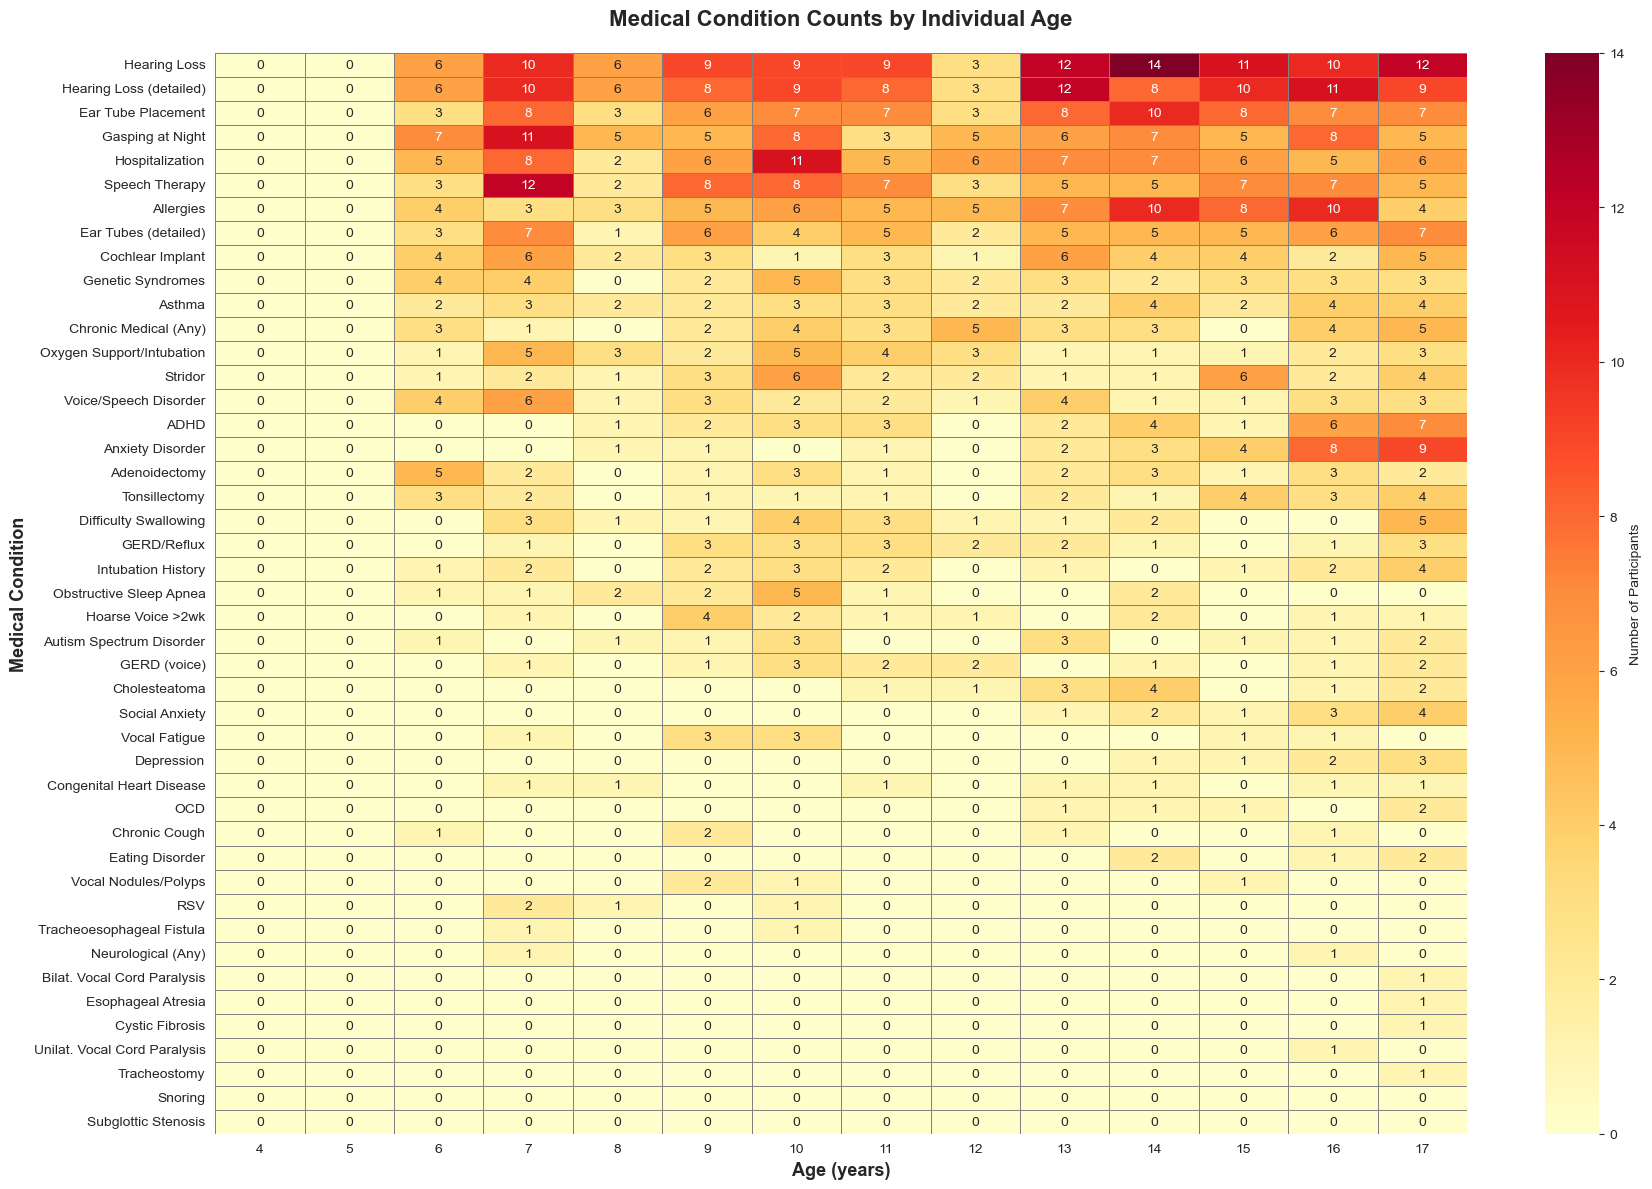

In [67]:
# Create heatmap for individual ages with raw counts
plt.figure(figsize=(18, 12))

# Create heatmap with custom colormap
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='g',  # general format for integers
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Participants'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0
)

plt.title('Medical Condition Counts by Individual Age', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age (years)', fontsize=13, fontweight='bold')
plt.ylabel('Medical Condition', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

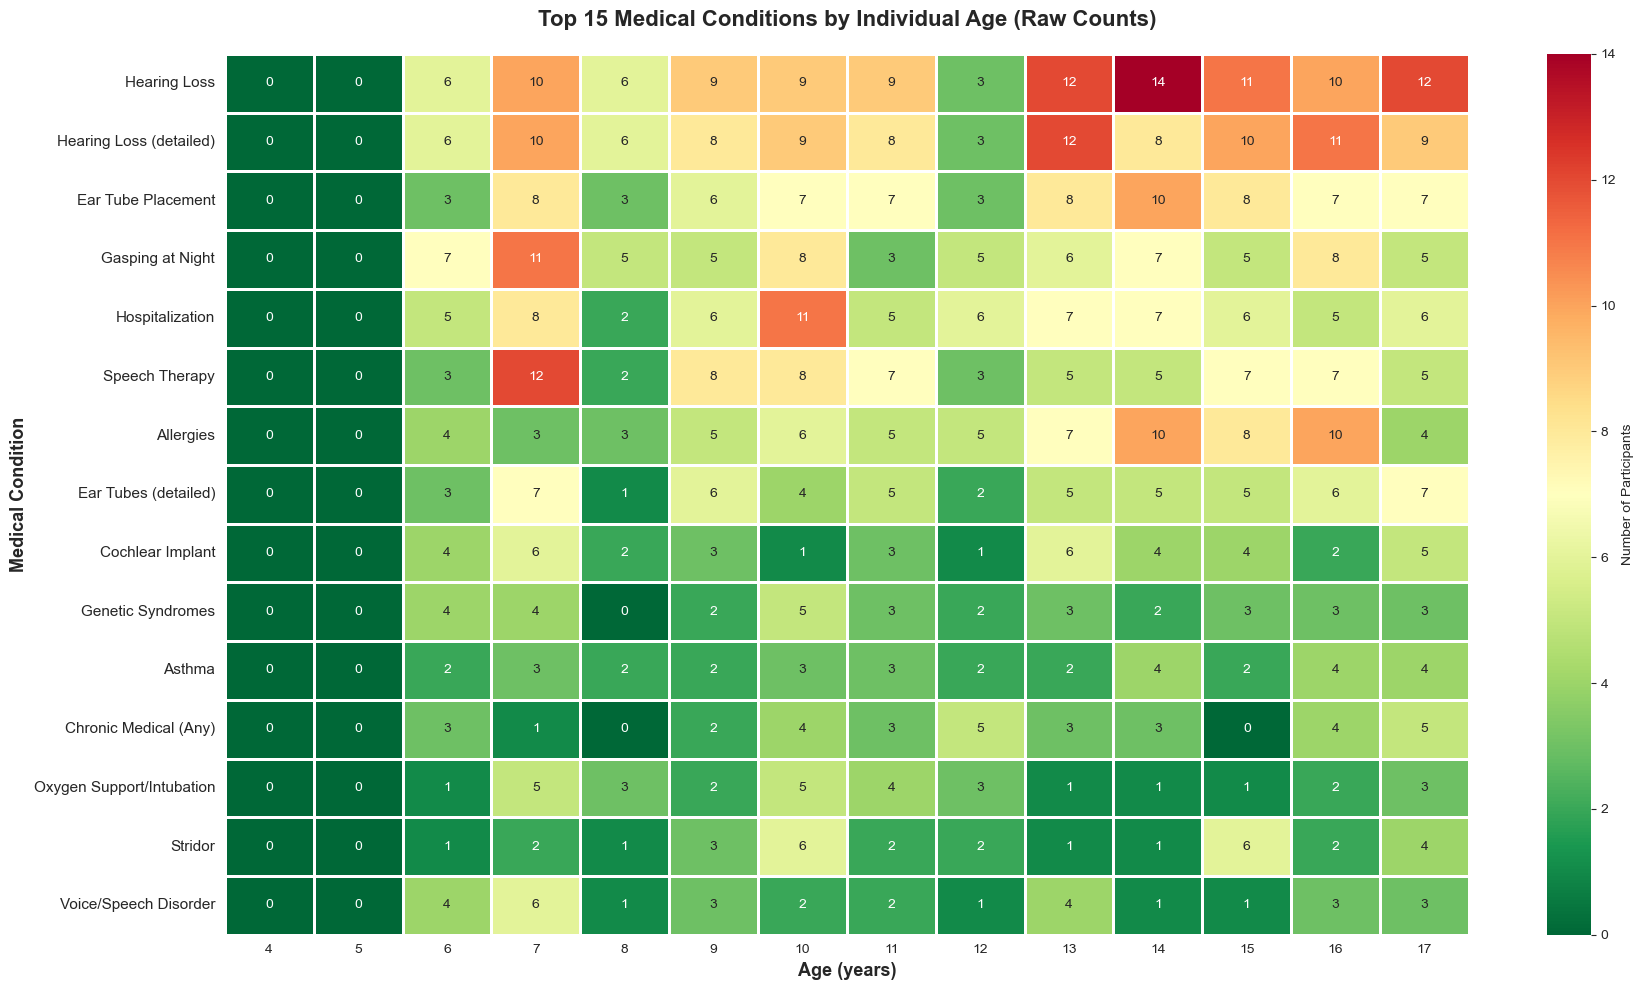

In [68]:
# Create a focused heatmap on top conditions only
top_n = 15
top_conditions = heatmap_df.head(top_n)

plt.figure(figsize=(18, 10))

ax = sns.heatmap(
    top_conditions,
    annot=True,
    fmt='g',  # general format for integers
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Number of Participants'},
    linewidths=1,
    linecolor='white',
    vmin=0
)

plt.title(f'Top {top_n} Medical Conditions by Individual Age (Raw Counts)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age (years)', fontsize=13, fontweight='bold')
plt.ylabel('Medical Condition', fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [69]:
# Summary statistics table with raw counts
summary_stats = pd.DataFrame({
    'Condition': heatmap_df.index,
    'Total Count': heatmap_df.sum(axis=1),
    'Min Count': heatmap_df.min(axis=1),
    'Max Count': heatmap_df.max(axis=1),
    'Range': (heatmap_df.max(axis=1) - heatmap_df.min(axis=1))
})

summary_stats = summary_stats.sort_values('Total Count', ascending=False)

print("\nMedical Condition Summary Statistics (Raw Counts):")
print(summary_stats.to_string(index=False))


Medical Condition Summary Statistics (Raw Counts):
                   Condition  Total Count  Min Count  Max Count  Range
                Hearing Loss          111          0         14     14
     Hearing Loss (detailed)          100          0         12     12
          Ear Tube Placement           77          0         10     10
            Gasping at Night           75          0         11     11
             Hospitalization           74          0         11     11
              Speech Therapy           72          0         12     12
                   Allergies           70          0         10     10
        Ear Tubes (detailed)           56          0          7      7
            Cochlear Implant           41          0          6      6
           Genetic Syndromes           34          0          5      5
       Chronic Medical (Any)           33          0          5      5
                      Asthma           33          0          4      4
   Oxygen Support/Intubat

In [70]:
# Add sample size annotations to understand the data
age_counts = df['age'].value_counts().sort_index()

print("\nSample sizes per age:")
for age in ages:
    n = age_counts.get(age, 0)
    print(f"  Age {age}: n={n}")


Sample sizes per age:
  Age 4: n=1
  Age 5: n=1
  Age 6: n=20
  Age 7: n=34
  Age 8: n=14
  Age 9: n=25
  Age 10: n=26
  Age 11: n=24
  Age 12: n=21
  Age 13: n=29
  Age 14: n=38
  Age 15: n=24
  Age 16: n=30
  Age 17: n=20
